# Proyecto LA Crime

## Carga de data set y librerias.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

crime = pd.read_csv('DataSets/Crime_Data_from_2020_to_Present_20260123.csv')

**Fuente del dataset y detalles:** https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8/about_data

## Exploracion Inicial de datos

In [2]:
crime.head() #Primeros 5 registros

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,2021 Apr 11 12:00:00 AM,2020 Nov 07 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,2020 Oct 21 12:00:00 AM,2020 Oct 18 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,2024 Dec 10 12:00:00 AM,2020 Oct 30 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,2020 Dec 24 12:00:00 AM,2020 Dec 24 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,2020 Oct 03 12:00:00 AM,2020 Sep 29 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [3]:
crime.columns #Columnas del DataFrame

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [4]:
crime.shape #Dimensiones del dataframe (Filas, Columnas)

(1004991, 28)

In [5]:
crime.dtypes #Tipos de datos de cada columno

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object

In [6]:
crime.isna().sum() #Conteo de datos NaN por columna

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151619
Vict Age                0
Vict Sex           144644
Vict Descent       144656
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677744
Weapon Desc        677744
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935831
Crm Cd 3          1002677
Crm Cd 4          1004927
LOCATION                0
Cross Street       850755
LAT                     0
LON                     0
dtype: int64

## Limpieza Inicial de DF y Cambio de index

In [7]:
CleanDF = crime.drop(labels = ['Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street', 'Mocodes', 
                               'AREA', 'Rpt Dist No', 'Part 1-2', 'Crm Cd','Premis Desc', 'Weapon Used Cd'], axis = 1)

In [8]:
CleanDF.set_index('DR_NO', inplace = True) #cambiamos el index por el numero oficial del archivo del crimen
CleanDF.sort_values(by = 'DATE OCC')

,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON
DR_NO,,,,,,,,,,,,,,,,
202108091,2020 Apr 07 12:00:00 AM,2020 Apr 01 12:00:00 AM,1200,Topanga,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,77,M,W,123.0,NaN,IC,Invest Cont,331.0,7300 WOODLAKE AV,34.2023,-118.6322
201210145,2020 Apr 01 12:00:00 AM,2020 Apr 01 12:00:00 AM,1500,77th Street,BATTERY - SIMPLE ASSAULT,58,M,B,102.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,624.0,45TH ST,34.0029,-118.2816
201808987,2020 Apr 01 12:00:00 AM,2020 Apr 01 12:00:00 AM,30,Southeast,VEHICLE - STOLEN,0,NaN,NaN,101.0,NaN,AA,Adult Arrest,510.0,300 E IMPERIAL HY,33.9345,-118.2623
211011189,2021 Aug 11 12:00:00 AM,2020 Apr 01 12:00:00 AM,800,West Valley,THEFT OF IDENTITY,24,F,B,602.0,NaN,IC,Invest Cont,354.0,8100 CANBY AV,34.2177,-118.5344
200208516,2020 Apr 01 12:00:00 AM,2020 Apr 01 12:00:00 AM,125,Rampart,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",27,M,K,501.0,NaN,IC,Invest Cont,740.0,100 S RENO ST,34.0714,-118.2813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250404166,2025 Mar 26 12:00:00 AM,2025 Mar 25 12:00:00 AM,1500,Hollenbeck,ROBBERY,14,M,H,101.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,210.0,MOTT ST,34.0405,-118.2070
251904210,2025 Mar 25 12:00:00 AM,2025 Mar 25 12:00:00 AM,1235,Mission,INDECENT EXPOSURE,35,F,H,721.0,NaN,IC,Invest Cont,850.0,11100 OMELVENY AV,34.2722,-118.4417
252104146,2025 Mar 26 12:00:00 AM,2025 Mar 26 12:00:00 AM,633,Topanga,CRIMINAL THREATS - NO WEAPON DISPLAYED,35,M,X,729.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,930.0,20800 BURBANK BL,34.1720,-118.5854


## Cambio de formato de las columnas con Fechas

**A continuacion se convierten las columnas fecha de objeto a datetime, se uso adicionalmente *dt.normalize()* para quitar la hora de las fechas.** 

In [9]:
CleanDF['DATE OCC'] = pd.to_datetime(CleanDF['DATE OCC'], format= '%Y %b %d %I:%M:%S %p')
CleanDF['Date Rptd'] = pd.to_datetime(CleanDF['Date Rptd'], format= '%Y %b %d %I:%M:%S %p')

In [10]:
CleanDF.dtypes

Date Rptd       datetime64[ns]
DATE OCC        datetime64[ns]
TIME OCC                 int64
AREA NAME               object
Crm Cd Desc             object
Vict Age                 int64
Vict Sex                object
Vict Descent            object
Premis Cd              float64
Weapon Desc             object
Status                  object
Status Desc             object
Crm Cd 1               float64
LOCATION                object
LAT                    float64
LON                    float64
dtype: object

## Usando Describe para obtener datos generales y Creando una variable con el filtro de edades mayores a 0 en el DF

In [11]:
CleanDF.describe(include = ['float64', 'int64'])

,TIME OCC,Vict Age,Premis Cd,Crm Cd 1,LAT,LON
count,1.004991e+06,1.004991e+06,1.004975e+06,1.004980e+06,1.004991e+06,1.004991e+06
mean,1.339900e+03,2.891706e+01,3.056201e+02,4.999174e+02,3.399821e+01,-1.180909e+02
std,6.510613e+02,2.199272e+01,2.193021e+02,2.050736e+02,1.610713e+00,5.582386e+00
min,1.000000e+00,-4.000000e+00,1.010000e+02,1.100000e+02,0.000000e+00,-1.186676e+02
25%,9.000000e+02,0.000000e+00,1.010000e+02,3.310000e+02,3.401470e+01,-1.184305e+02
50%,1.420000e+03,3.000000e+01,2.030000e+02,4.420000e+02,3.405890e+01,-1.183225e+02
75%,1.900000e+03,4.400000e+01,5.010000e+02,6.260000e+02,3.416490e+01,-1.182739e+02
max,2.359000e+03,1.200000e+02,9.760000e+02,9.560000e+02,3.433430e+01,0.000000e+00


Hay datos de edad en 0 o menos asi que vamos a ponerlos en otro data frame, lo vamos a dejar en otro DF por que 0 en registros de crimen puede significar edad desconocida

In [12]:
df_age = CleanDF[CleanDF['Vict Age'] > 0]

In [13]:
df_age.describe(include = ['float64','int64'])

,TIME OCC,Vict Age,Premis Cd,Crm Cd 1,LAT,LON
count,735632.000000,735632.000000,735631.000000,735626.000000,735632.000000,735632.000000
mean,1326.711583,39.505584,335.162558,497.171009,33.997383,-118.085021
std,651.056461,15.571448,217.194913,220.305258,1.636065,5.670740
min,1.000000,2.000000,101.000000,110.000000,0.000000,-118.667600
25%,900.000000,28.000000,104.000000,330.000000,34.015500,-118.433500
50%,1400.000000,37.000000,404.000000,440.000000,34.059200,-118.326500
75%,1845.000000,50.000000,502.000000,626.000000,34.166400,-118.276000
max,2359.000000,120.000000,976.000000,956.000000,34.334300,0.000000


In [14]:
df_age.shape

(735632, 16)

In [15]:
CleanDF.shape

(1004991, 16)

In [16]:
df_age['Vict Age'].value_counts()

Vict Age
30     22289
35     21836
31     21420
29     21345
28     20969
       ...  
95       100
96        94
97        72
98        71
120        1
Name: count, Length: 99, dtype: int64

## Creando columnas de año y mes en que ocurrio el crimen para futura exploracion

In [17]:
CleanDF['Crime Year'] = CleanDF['DATE OCC'].dt.year
CleanDF['Crime Month'] = CleanDF['DATE OCC'].dt.month

# Feature Understanding

<Axes: xlabel='Crime Month'>

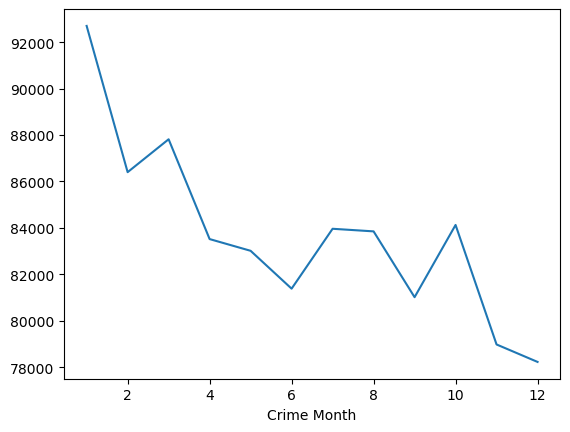

In [18]:
CleanDF['Crime Month'].value_counts().sort_index().plot()

<Axes: xlabel='Crime Year'>

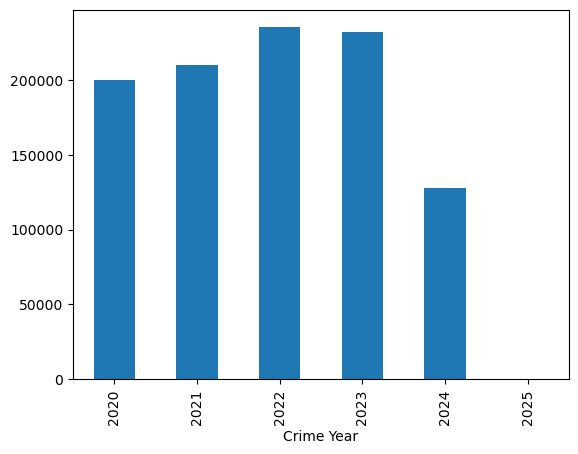

In [19]:
CleanDF['Crime Year'].value_counts().sort_index().plot(kind= 'bar')

In [20]:
CleanDF = CleanDF[~(CleanDF['Crime Year'] == 2025)] #2025 parecia incompleto asi que se excluye

In [21]:
CleanDF.groupby(['Crime Year','Crime Month']).size() #Muestra registros separados por año y mes

Crime Year  Crime Month
2020        1              18576
            2              17284
            3              16188
            4              15706
            5              17230
            6              17060
            7              17158
            8              16902
            9              15658
            10             16510
            11             15596
            12             15979
2021        1              16636
            2              15440
            3              16354
            4              16091
            5              17020
            6              17182
            7              18690
            8              18398
            9              18386
            10             19343
            11             18374
            12             17962
2022        1              18567
            2              17750
            3              19745
            4              19837
            5              20467
            6      

<Axes: xlabel='Crime Year,Crime Month'>

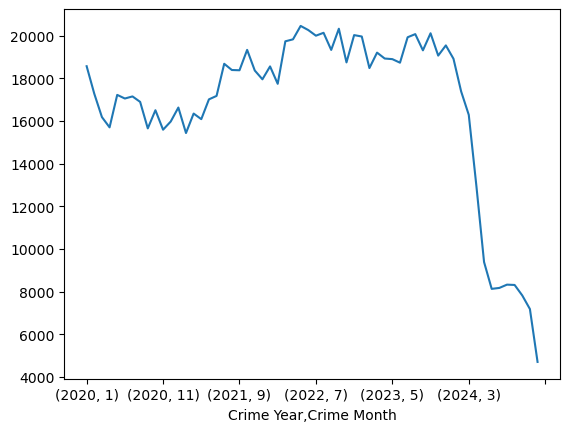

In [22]:
CleanDF.groupby(['Crime Year','Crime Month']).size().plot()

(array([1.08060e+04, 1.28866e+05, 2.43588e+05, 1.63130e+05, 1.06441e+05,
        6.09000e+04, 1.81450e+04, 3.25800e+03, 4.97000e+02, 1.00000e+00]),
 array([  2. ,  13.8,  25.6,  37.4,  49.2,  61. ,  72.8,  84.6,  96.4,
        108.2, 120. ]),
 <BarContainer object of 10 artists>)

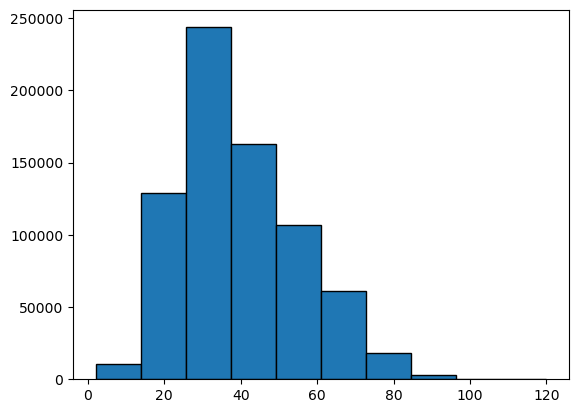

In [23]:
plt.hist(df_age['Vict Age'], edgecolor = 'Black')

In [24]:
CleanDF

,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,Crime Year,Crime Month
DR_NO,,,,,,,,,,,,,,,,,,
211507896,2021-04-11,2020-11-07,845,N Hollywood,THEFT OF IDENTITY,31,M,H,501.0,NaN,IC,Invest Cont,354.0,7800 BEEMAN AV,34.2124,-118.4092,2020,11
201516622,2020-10-21,2020-10-18,1845,N Hollywood,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",32,M,H,102.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,ATOLL AV,34.1993,-118.4203,2020,10
240913563,2024-12-10,2020-10-30,1240,Van Nuys,THEFT OF IDENTITY,30,M,W,501.0,NaN,IC,Invest Cont,354.0,14600 SYLVAN ST,34.1847,-118.4509,2020,10
210704711,2020-12-24,2020-12-24,1310,Wilshire,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,47,F,A,101.0,NaN,IC,Invest Cont,331.0,6000 COMEY AV,34.0339,-118.3747,2020,12
201418201,2020-10-03,2020-09-29,1830,Pacific,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),63,M,H,103.0,NaN,IC,Invest Cont,420.0,4700 LA VILLA MARINA,33.9813,-118.4350,2020,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240710284,2024-07-24,2024-07-23,1400,Wilshire,VEHICLE - STOLEN,0,NaN,NaN,101.0,NaN,IC,Invest Cont,510.0,4000 W 23RD ST,34.0362,-118.3284,2024,7
240104953,2024-01-15,2024-01-15,100,Central,VANDALISM - MISDEAMEANOR ($399 OR UNDER),0,X,X,503.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,745.0,1300 W SUNSET BL,34.0685,-118.2460,2024,1
240410786,2024-10-14,2024-10-11,2330,Hollenbeck,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",29,M,B,210.0,NaN,IC,Invest Cont,341.0,1700 ALBION ST,34.0675,-118.2240,2024,10


In [25]:
Crime_count_per_day = CleanDF.groupby(['DATE OCC', 'Crm Cd Desc']).size()

In [26]:
top20crimes = Crime_count_per_day.groupby('Crm Cd Desc').mean().reset_index(name = 'average daily count')\
    .sort_values(by = 'average daily count', ascending = False).head(20)

<BarContainer object of 20 artists>

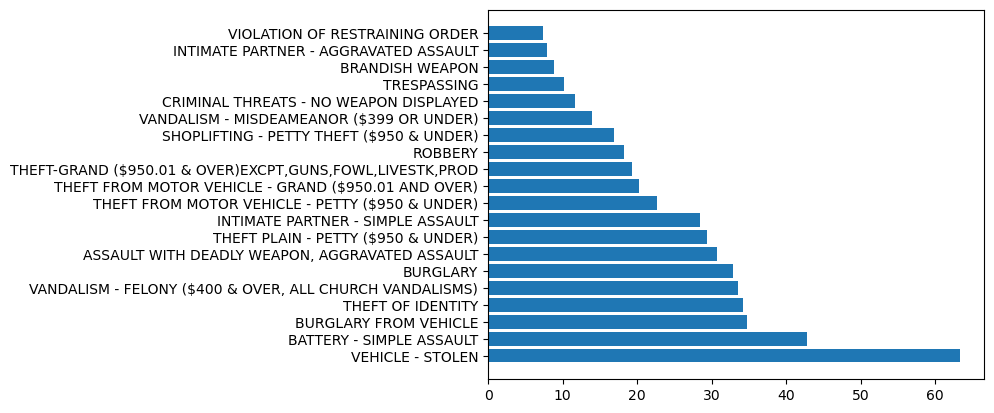

In [27]:
plt.barh(top20crimes['Crm Cd Desc'], top20crimes['average daily count'])

In [28]:
top20crimes_sorted = top20crimes.sort_values(by='average daily count')

<BarContainer object of 20 artists>

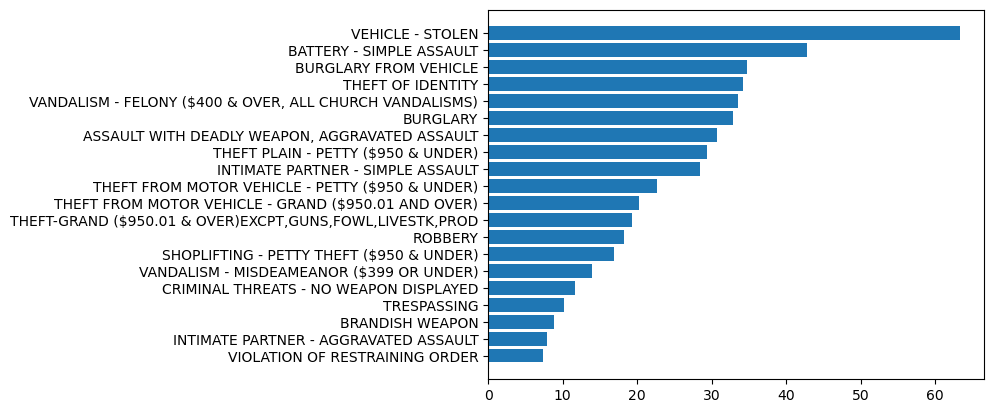

In [29]:
plt.barh(top20crimes_sorted['Crm Cd Desc'], top20crimes_sorted['average daily count'])

<BarContainer object of 20 artists>

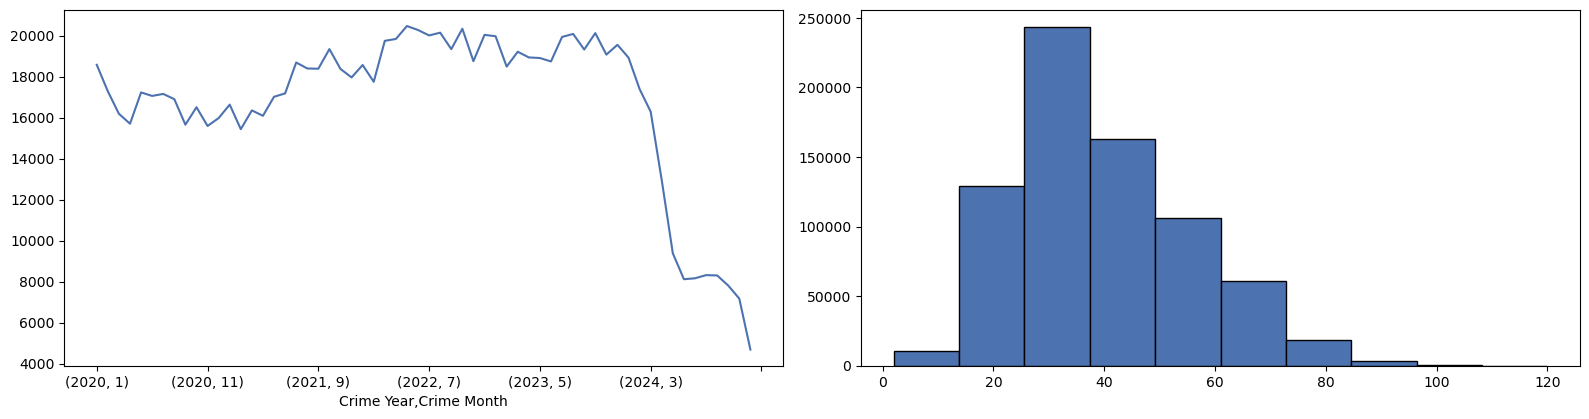

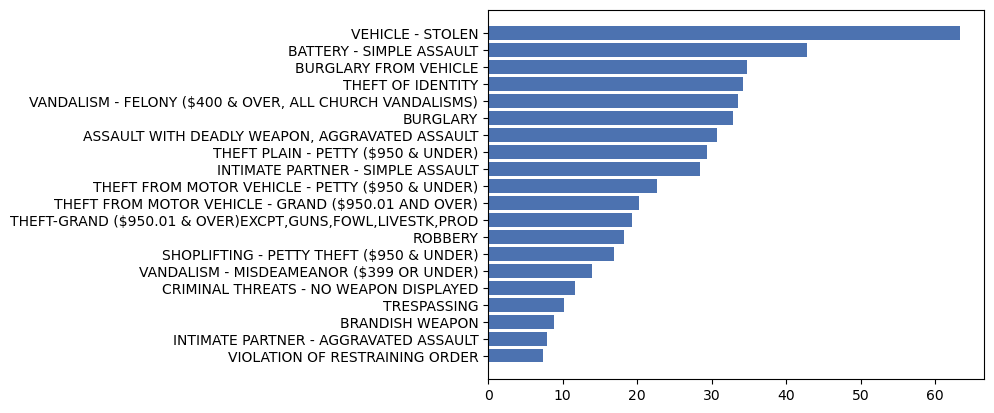

In [30]:
plt.style.use('seaborn-v0_8-deep')

plt.figure(figsize = (16, 8))

plt.subplot(2,2,1)
CleanDF.groupby(['Crime Year','Crime Month']).size().plot()

plt.subplot(2,2,2)
plt.hist(df_age['Vict Age'], edgecolor = 'Black')

plt.tight_layout()

plt.figure()
plt.barh(top20crimes_sorted['Crm Cd Desc'], top20crimes_sorted['average daily count'])

## Estudiando algunos datos

**Tiempo que se demoraron en reportar**

Para obtener el tiempo que se demoran en reportrar simplemente restamos dia del reporte y dia del crimen

In [31]:
CleanDF['Demora para reportar en dias'] = CleanDF['Date Rptd'] - CleanDF['DATE OCC']

In [32]:
CleanDF

,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,Crime Year,Crime Month,Demora para reportar en dias
DR_NO,,,,,,,,,,,,,,,,,,,
211507896,2021-04-11,2020-11-07,845,N Hollywood,THEFT OF IDENTITY,31,M,H,501.0,NaN,IC,Invest Cont,354.0,7800 BEEMAN AV,34.2124,-118.4092,2020,11,155 days
201516622,2020-10-21,2020-10-18,1845,N Hollywood,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",32,M,H,102.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,ATOLL AV,34.1993,-118.4203,2020,10,3 days
240913563,2024-12-10,2020-10-30,1240,Van Nuys,THEFT OF IDENTITY,30,M,W,501.0,NaN,IC,Invest Cont,354.0,14600 SYLVAN ST,34.1847,-118.4509,2020,10,1502 days
210704711,2020-12-24,2020-12-24,1310,Wilshire,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,47,F,A,101.0,NaN,IC,Invest Cont,331.0,6000 COMEY AV,34.0339,-118.3747,2020,12,0 days
201418201,2020-10-03,2020-09-29,1830,Pacific,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),63,M,H,103.0,NaN,IC,Invest Cont,420.0,4700 LA VILLA MARINA,33.9813,-118.4350,2020,9,4 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240710284,2024-07-24,2024-07-23,1400,Wilshire,VEHICLE - STOLEN,0,NaN,NaN,101.0,NaN,IC,Invest Cont,510.0,4000 W 23RD ST,34.0362,-118.3284,2024,7,1 days
240104953,2024-01-15,2024-01-15,100,Central,VANDALISM - MISDEAMEANOR ($399 OR UNDER),0,X,X,503.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,745.0,1300 W SUNSET BL,34.0685,-118.2460,2024,1,0 days
240410786,2024-10-14,2024-10-11,2330,Hollenbeck,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",29,M,B,210.0,NaN,IC,Invest Cont,341.0,1700 ALBION ST,34.0675,-118.2240,2024,10,3 days


In [33]:
ReportadosEnLosPrimeros31Dias = CleanDF.groupby(['Demora para reportar en dias'])\
    .size().reset_index(name='Conteo de Registros')\
    .sort_values(by = 'Demora para reportar en dias')

In [34]:
ReportadosEnLosPrimeros31Dias #esto es por si se me antoja hacer graficos de cuanto demoran en reportar

,Demora para reportar en dias,Conteo de Registros
0,0 days,482015
1,1 days,222376
2,2 days,64436
3,3 days,37527
4,4 days,24121
...,...,...
1468,1784 days,1
1469,1791 days,1
1470,1795 days,1
1471,1796 days,1


In [35]:
CleanDF.groupby(['Crm Cd Desc'])['Demora para reportar en dias'].mean().sort_values().head(20)

Crm Cd Desc
TRAIN WRECKING                                                       0 days 00:00:00
DISRUPT SCHOOL                                             0 days 01:50:46.153846153
PURSE SNATCHING - ATTEMPT                                  0 days 01:50:46.153846153
PETTY THEFT - AUTO REPAIR                                            0 days 03:00:00
LYNCHING                                                   0 days 03:16:21.818181818
FIREARMS RESTRAINING ORDER (FIREARMS RO)                             0 days 06:00:00
BATTERY POLICE (SIMPLE)                                    0 days 08:35:55.789473684
REPLICA FIREARMS(SALE,DISPLAY,MANUFACTURE OR DISTRIBUTE)   0 days 09:13:50.769230769
FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)                   0 days 09:36:00
BOMB SCARE                                                 0 days 11:46:14.522292993
FAILURE TO DISPERSE                                                  0 days 12:00:00
THEFT, COIN MACHINE - ATTEMPT                        

In [36]:
df_age.groupby('Crm Cd Desc')['Vict Age'].mean().reset_index().sort_values(by = 'Vict Age', ascending = False)

,Crm Cd Desc,Vict Age
45,DISHONEST EMPLOYEE ATTEMPTED THEFT,60.000000
54,DRUNK ROLL - ATTEMPT,58.000000
12,BLOCKING DOOR INDUCTION CENTER,54.666667
78,LYNCHING,53.000000
63,GRAND THEFT / AUTO REPAIR,52.333333
...,...,...
24,CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT,11.804264
25,CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT,11.526331
23,CHILD ABANDONMENT,11.000000
38,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,10.657143


## Buscando el area con mas crimen nocturno

In [38]:
nighttime = CleanDF[(CleanDF['DATE OCC'].dt.hour >= 20) | (CleanDF['DATE OCC'].dt.hour <= 4)]

In [40]:
nighttime['AREA NAME'].value_counts()

AREA NAME
Central        69668
77th Street    61756
Pacific        59513
Southwest      57434
Hollywood      52429
N Hollywood    51106
Olympic        50070
Southeast      49929
Newton         49173
Wilshire       48237
Rampart        46824
West LA        45725
Northeast      42951
Van Nuys       42881
West Valley    42146
Devonshire     41743
Harbor         41392
Topanga        41365
Mission        40342
Hollenbeck     37081
Foothill       33129
Name: count, dtype: int64